# 04. toy anomaly -- 학습 시 빈 타깃과 모델별 `train_step` 분기

Anomaly Detection은 지금까지 본 3개 태스크와 근본적으로 다르다: **학습에 라벨이 전혀 필요 없다**
(정상 이미지만으로 재구성 오차를 배운다). 이 노트북은 (1) 학습 target이 빈 dict `{}`인 이유,
(2) 어댑터가 아니라 모델이 자신만의 `train_step`을 정의해 학습 방식을 스스로 결정하는 경우,
(3) `on_fit_end` 훅이 threshold를 계산할 때 test loader를 절대 보지 않는다는 사실을 코드로
확인한다.

In [1]:
import os
import sys


def find_repo_root(start):
    """Walk up from the notebook's own directory to the repository root (identified by the
    presence of `src/`), so `import src...` resolves regardless of where this notebook is run
    from (nbconvert executes with cwd set to the notebook's own directory)."""
    path = os.path.abspath(start)
    while not os.path.isdir(os.path.join(path, "src")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("could not locate repository root (no 'src/' found above cwd)")
        path = parent
    return path


REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# Mirrors src/__main__.py: arm the offline guard before any module that might touch the
# network at import time, then import src.tasks so every @DATASETS/@MODELS/@ADAPTERS/...
# decorator across the 4 tasks (+ toy) actually runs and populates the registries. Until this
# import happens, every Registry in src.core.registry is empty.
from src.core.offline import enable_offline_guard

enable_offline_guard()
import src.tasks  # noqa: F401,E402

print("cwd:", os.getcwd())

import torch

cwd: /mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate


## 데이터 -- train은 빈 target, valid/test는 라벨+마스크

`src/tasks/toy/dataset.py`의 `ToyAnomalyDataset`은 `split == "train"`일 때 target으로 빈 dict
`{}`를 반환한다. 정상 이미지만 있는 train split에는 애초에 라벨을 줄 필요가 없기 때문이다. valid/test
split은 절반이 인위적으로 결함을 주입한 이상 이미지이며, `label`(0/1)과 `mask`(픽셀 단위 0/1)를
함께 반환한다.

In [2]:
from src.core.registry import DATASETS

train_ds = DATASETS.build("toy_anomaly", root=".", split="train", transform=None, image_size=(32, 32))
valid_ds = DATASETS.build("toy_anomaly", root=".", split="valid", transform=None, image_size=(32, 32))

train_image, train_target = train_ds[0]
print("train sample -- image:", train_image.shape, " target:", train_target, "(empty dict)")

valid_image, valid_target = valid_ds[0]
valid_image1, valid_target1 = valid_ds[1]
print("valid sample 0 -- label:", int(valid_target["label"]), " mask sum:", float(valid_target["mask"].sum()))
print("valid sample 1 -- label:", int(valid_target1["label"]), " mask sum:", float(valid_target1["mask"].sum()))

train sample -- image: torch.Size([3, 32, 32])  target: {} (empty dict)
valid sample 0 -- label: 0  mask sum: 0.0
valid sample 1 -- label: 1  mask sum: 64.0


`idx % 2 == 1`인 valid 샘플만 결함이 주입되므로 (`is_anomalous = idx % 2 == 1`), 인덱스 0은
정상(label=0, mask 전부 0), 인덱스 1은 이상(label=1, mask 일부 1)이다.

## `collate_fn` -- 이미지는 스택, target은 list 유지

여기서 target 딕셔너리 자체는 사실 `default_collate`로도 쌓을 수 있다 -- `{"label": 0, "mask": ...}`
같은 동일한 키를 가진 dict들의 리스트를 주면, PyTorch 기본 `default_collate`는 dict를 재귀적으로
순회해 `{"label": stacked_tensor, "mask": stacked_tensor}` 형태의 **단일 dict**를 만들어 낸다.
문제는 `ToyAnomalyAdapter.eval_step`이 `for t in targets: t["label"]`처럼 **샘플별 dict의
리스트**를 기대한다는 점이다 -- `default_collate`가 만드는 구조(리스트가 dict로 접혀버린 것)와
어댑터가 기대하는 구조(dict의 리스트)가 다르다. `anomaly_collate`는 이미지만 텐서로 스택하고
target은 원래의 "샘플별 dict 리스트" 구조를 그대로 보존한다.

In [3]:
import inspect
from src.tasks.toy.collate import anomaly_collate

print(inspect.getsource(anomaly_collate))

def anomaly_collate(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    targets = [item[1] for item in batch]
    return images, targets



In [4]:
from src.core.registry import ADAPTERS
from torch.utils.data import DataLoader

ToyAnomalyAdapter = ADAPTERS.get("toy_anomaly")
adapter = ToyAnomalyAdapter(loss_fn=torch.nn.MSELoss(), metrics={})

train_loader = DataLoader(train_ds, batch_size=8, shuffle=False, collate_fn=adapter.collate_fn())
batch_images, batch_targets = next(iter(train_loader))
print("batch images:", batch_images.shape)
print("batch targets:", batch_targets[:2], "... (all empty dicts during training)")

batch images: torch.Size([8, 3, 32, 32])
batch targets: [{}, {}] ... (all empty dicts during training)


## 모델별 `train_step` 분기

`src/tasks/toy/adapter.py`의 `run_model_step`이 학습 스텝을 만든다. 눈여겨볼 지점: **모델이
`train_step` 메서드를 직접 정의하고 있으면 어댑터는 그것을 그대로 위임**하고, 없으면 어댑터가
`loss_fn(outputs, image)`로 기본 재구성 loss를 계산한다.

In [5]:
from src.tasks.toy.adapter import run_model_step

print(inspect.getsource(run_model_step))

def run_model_step(model, images, targets, loss_fn, reconstruction_target=None):
    if hasattr(model, "train_step"):
        return model.train_step(images, targets)
    outputs = model(images)
    loss_target = images if reconstruction_target == "self" else targets
    loss = loss_fn(outputs, loss_target)
    return {"loss": loss, "loss_dict": {"loss": float(loss.detach())}}



`toy_ae`(`ToyAutoencoder`)는 `train_step`을 정의하지 않는다 -- 기본 경로를 탄다. 반면
`toy_ae_trainstep`(`ToyAutoencoderTrainStep`)은 재구성 loss에 smoothness 정규화 항을 더한 자신만의
`train_step`을 정의한다. 두 모델 모두 같은 `toy_anomaly` 어댑터, 같은 config로 학습시켜 실제로
다른 경로를 타는지 확인한다.

In [6]:
from src.core.registry import MODELS

default_model = MODELS.build("toy_ae")
custom_model = MODELS.build("toy_ae_trainstep")

print("toy_ae has model-defined train_step:", hasattr(default_model, "train_step"))
print("toy_ae_trainstep has model-defined train_step:", hasattr(custom_model, "train_step"))

sample_images = batch_images
default_step = run_model_step(default_model, sample_images, {}, torch.nn.MSELoss(),
                               reconstruction_target="self")
custom_step = run_model_step(custom_model, sample_images, {}, torch.nn.MSELoss(),
                              reconstruction_target="self")

print("\ndefault path loss_dict:", default_step["loss_dict"])
print("custom path loss_dict: ", custom_step["loss_dict"], "-- has 'recon_loss'/'smoothness', not just 'loss'")

toy_ae has model-defined train_step: False
toy_ae_trainstep has model-defined train_step: True

default path loss_dict: {'loss': 1.007022500038147}
custom path loss_dict:  {'recon_loss': 1.0025818347930908, 'smoothness': 0.032524481415748596} -- has 'recon_loss'/'smoothness', not just 'loss'


`default_step`은 `run_model_step`이 만든 `{"loss": ..., "loss_dict": {"loss": ...}}` 하나뿐이고,
`custom_step`은 모델이 직접 반환한 `{"recon_loss": ..., "smoothness": ...}`다 -- **같은 어댑터가
모델에 따라 실제로 다른 코드 경로를 실행**한다는 것을 loss_dict의 키 차이로 확인했다.

## 학습 -- 5 epoch, CPU (기본 경로 `toy_ae`)

In [7]:
import os

from src.cli.commands import bind_class_names, build_components, build_dataset, build_transforms
from src.core.builders import build_dataloader, build_optimizer, build_scheduler
from src.core.config import resolve_config, validate_config
from src.core.context import RunContext
from src.core.engine import Trainer
from src.core.logger import MetricsCsvWriter, setup_logger

config = validate_config(resolve_config("configs/toy/toy_anomaly.yaml"))
run_dir = os.path.join("outputs", "notebooks", "04_toy_anomaly")
os.makedirs(run_dir, exist_ok=True)

ctx = RunContext(config, run_dir)
ctx.setup_seed()

transform_train, transform_eval = build_transforms(config)
model, adapter = build_components(config)
adapter.to(ctx.device)
train_ds2 = build_dataset(config, "train", transform_train)
valid_ds2 = build_dataset(config, "valid", transform_eval)
bind_class_names(adapter, train_ds2)

train_loader2 = build_dataloader(train_ds2, config["data"], "train", adapter, ctx.seed,
                                  config["runtime"]["device"])
valid_loader2 = build_dataloader(valid_ds2, config["data"], "valid", adapter, ctx.seed,
                                  config["runtime"]["device"])
optimizer = build_optimizer(config["optim"], model)
scheduler = build_scheduler(config["optim"], optimizer)

logger = setup_logger(run_dir, "WARNING")
metrics_writer = MetricsCsvWriter(run_dir, [m["name"] for m in config["metrics"]])
trainer = Trainer(logger=logger, metrics_writer=metrics_writer,
                   checkpoint_dir=os.path.join(run_dir, "checkpoints"))

print("adapter.threshold before fit():", adapter.threshold)

adapter.threshold before fit(): None


## `on_fit_end`가 받는 loader -- test는 절대 전달되지 않는다

`Trainer.fit`(00_engine.ipynb 4장)은 `loaders = {"train": train_loader, "valid": valid_loader}`만
만들어 훅에 넘긴다. `test` 키는 애초에 이 딕셔너리에 존재하지 않는다. threshold를 valid로만 정하고
test로 정하지 않는 것은 평가 누수(test leakage)를 막기 위한 설계다. 어댑터의 `on_fit_end`를
가로채서(spy) 실제로 어떤 키가 들어오는지 직접 확인한다.

In [8]:
received_loader_keys = {}
original_on_fit_end = adapter.on_fit_end


def spy_on_fit_end(model_arg, loaders, device_arg):
    received_loader_keys["keys"] = set(loaders.keys())
    return original_on_fit_end(model_arg, loaders, device_arg)


adapter.on_fit_end = spy_on_fit_end

best = trainer.fit(model, adapter, train_loader2, valid_loader2, optimizer, scheduler, ctx)

print("loaders dict keys seen by on_fit_end:", received_loader_keys["keys"])
assert received_loader_keys["keys"] == {"train", "valid"}, "on_fit_end must never see a 'test' loader"
print("best valid image_auroc:", best)
print("adapter.threshold after fit():", adapter.threshold)

loaders dict keys seen by on_fit_end: {'valid', 'train'}
best valid image_auroc: 1.0
adapter.threshold after fit(): 27.16407012939453


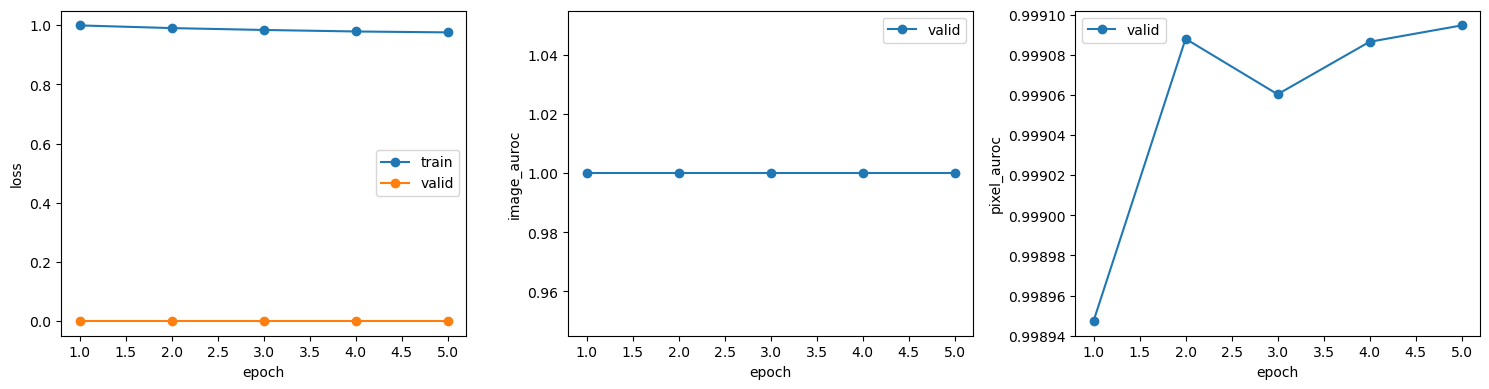

,epoch,split,loss,image_auroc,pixel_auroc,lr,elapsed_sec
0,1,train,0.999308,NaN,NaN,0.001000,0.102878
1,1,valid,0.000000,1.0,0.998947,0.000000,0.019088
2,2,train,0.990256,NaN,NaN,0.000905,0.032009
3,2,valid,0.000000,1.0,0.999088,0.000000,0.014515
4,3,train,0.983932,NaN,NaN,0.000658,0.032578
5,3,valid,0.000000,1.0,0.999060,0.000000,0.014017
6,4,train,0.978816,NaN,NaN,0.000352,0.031535
7,4,valid,0.000000,1.0,0.999086,0.000000,0.013639
8,5,train,0.975771,NaN,NaN,0.000105,0.033303
9,5,valid,0.000000,1.0,0.999095,0.000000,0.013832


In [9]:
from notebooks.common import plot_training_curves

plot_training_curves(os.path.join(run_dir, "metrics_epoch.csv"), ["image_auroc", "pixel_auroc"])

## 요약

- Anomaly Detection의 train target은 빈 dict `{}`다 -- 학습에는 라벨이 필요 없다는 이 태스크의
  근본 성질이 target 규약에 그대로 드러난다.
- `Trainer`는 어느 경우든 `ToyAnomalyAdapter.train_step`을 호출한다 -- 어댑터 경계 자체는 항상
  지켜진다. 다만 어댑터 내부의 `run_model_step`이 모델이 `train_step`을 직접 정의했는지로 분기한다:
  대부분의 모델은 어댑터가 제공하는 기본 재구성 loss 경로를 타지만, `toy_ae_trainstep`처럼 자신만의
  loss 구성(정규화 항 추가 등)이 필요한 모델은 그 기본 경로만 우회하고 직접 loss를 정의한다.
- `on_fit_end`가 받는 `loaders` 딕셔너리에는 `"train"`/`"valid"`만 있고 `"test"`는 없다 -- threshold
  같은 보정값이 test 데이터를 보고 정해지는 것을 구조적으로 막는다.

`toy/` 5개 노트북에서 4개 태스크의 target 규약(스칼라/`(H,W)`/가변 N/빈 dict)과 엔진의 계약을
모두 확인했다. `tasks/` 노트북부터는 동일한 계약이 실데이터와 실제 학습된 체크포인트 위에서
어떻게 나타나는지를 본다.